# Fine-Tuning

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [2]:
train_df = np.load("embeddings/train_embeddings_belgium.npz")

test_df = np.load("embeddings/test_embeddings_belgium.npz")

In [3]:
meta_train = [train_df['y'], train_df['w']]

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
# ---------------------------------------------------------
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# ---------------------------------------------------------
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Fast Reconstruction
# ---------------------------------------------------------
# Because indices are preserved, pandas aligns rows automatically.

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  100
Final Train Shape:   (500000, 102)
         PC1        PC2       PC3       PC4        PC5       PC6       PC7  \
0 -20.757276   0.276835 -7.000531  9.728931   3.760087  7.537823  6.343600   
1 -18.190178 -24.196190  5.108081 -3.762100   1.702171  6.620339  0.380923   
2 -18.192116 -24.142666  5.125678 -3.694812   1.796355  6.635554  0.391211   
3 -25.501200   7.364455  4.621192 -7.885581   0.555938  0.952227  2.209950   
4 -18.008513  -9.018816  6.287236  2.159208 -15.499185  3.843984 -1.194945   

        PC8       PC9      PC10  ...      PC93      PC94      PC95      PC96  \
0 -5.814025  2.678177  7.644933  ...  0.215755 -0.565011 -0.369545 -0.095292   
1  3.671964 -1.810245  1.434707  ... -0.227062  0.334448 -0.194110  0.515249   
2  3.661011 -1.837625  1.379988  ... -0.216125  0.302812 -0.154724  0.542495   
3  5.531308 -5.257185  0.373697  ...  1.208654  0.138627  0.319900 -0.581647   
4  5.242546 -0.248387  1.046400  ... -0.466

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,15.206360,15.206360
1,PC2,10.887949,26.094308
2,PC3,8.907615,35.001924
3,PC4,6.826991,41.828914
4,PC5,5.994005,47.822919
...,...,...,...
95,PC96,0.035292,98.249236
96,PC97,0.034355,98.283591
97,PC98,0.033926,98.317517
98,PC99,0.032662,98.350178


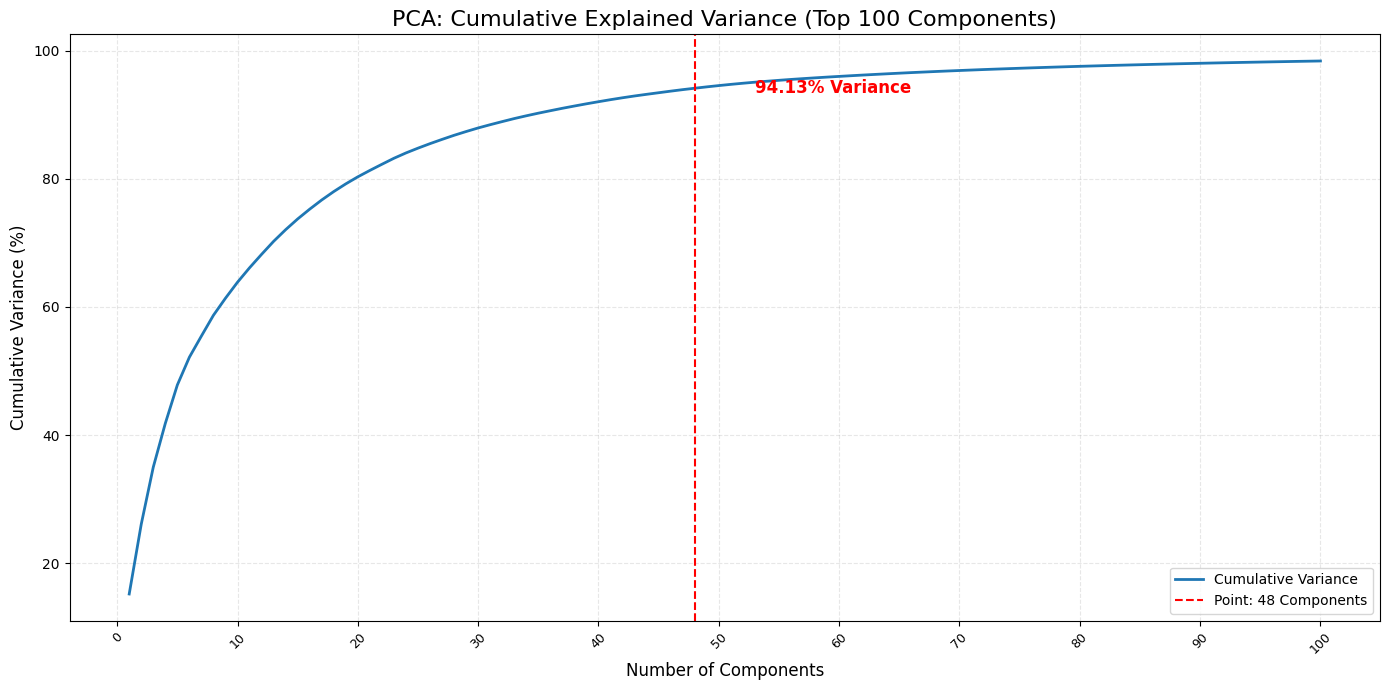

In [6]:
import matplotlib.pyplot as plt

# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

In [7]:
import pandas as pd

# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_train.shape[1])]

# Create the DataFrame
# usage of copy=False (optional) helps save memory by avoiding duplicating the large matrix
X_train = pd.DataFrame(X_train, columns=col_names, copy=False)

print(X_train.head())

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.003168    -0.009949    -0.013626     0.042877     0.073547   
1    -0.002342    -0.016190    -0.013893     0.044189     0.072205   
2    -0.002342    -0.016098    -0.013893     0.044067     0.072205   
3    -0.001658    -0.011215    -0.013611     0.050354     0.075623   
4    -0.001143    -0.012238    -0.013786     0.046021     0.074646   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  ...  \
0    -0.032990     0.006290     0.038452    -0.026291     -0.037018  ...   
1    -0.037781     0.004211     0.036377    -0.027649     -0.039337  ...   
2    -0.037659     0.004200     0.036407    -0.027725     -0.039337  ...   
3    -0.032715     0.005726     0.042511    -0.026077     -0.040436  ...   
4    -0.033600     0.003296     0.040955    -0.027588     -0.040253  ...   

   embedding_1015  embedding_1016  embedding_1017  embedding_1018  \
0        0.016190        0.016846       -0.005501    

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [8]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_test.shape[1])]

# Create the DataFrame
# usage of copy=False (optional) helps save memory by avoiding duplicating the large matrix
X_test = pd.DataFrame(X_test, columns=col_names, copy=False)


In [9]:
X_test

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,...,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023,embedding_1024
0,-0.003201,-0.009850,-0.013603,0.042877,0.073608,-0.032990,0.006348,0.038544,-0.026291,-0.037018,...,0.016205,0.016830,-0.005493,-0.006268,0.008858,0.053406,-0.008621,0.013977,0.032806,-0.003803
1,-0.001690,-0.011154,-0.013618,0.050201,0.075623,-0.032684,0.005779,0.042358,-0.026001,-0.040466,...,0.013885,0.014854,-0.007366,-0.009369,0.007481,0.054657,-0.007416,0.018784,0.031219,-0.002008
2,-0.004406,-0.004955,-0.013535,0.048920,0.075317,-0.032562,0.003487,0.040466,-0.028030,-0.037476,...,0.012039,0.011993,-0.006641,-0.008530,0.007889,0.054565,-0.010826,0.017868,0.030319,-0.001695
3,-0.003365,-0.012703,-0.013611,0.043854,0.073853,-0.031738,0.005547,0.040771,-0.028610,-0.040070,...,0.015266,0.017838,-0.005230,-0.006546,0.007416,0.051392,-0.007378,0.015556,0.032379,-0.002502
4,-0.004734,-0.011230,-0.013741,0.044739,0.072937,-0.033722,0.004486,0.042084,-0.025223,-0.038544,...,0.014427,0.017365,-0.006565,-0.004536,0.009079,0.053528,-0.009644,0.015465,0.031082,-0.002804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.003277,-0.007046,-0.013931,0.045044,0.071838,-0.032135,0.007805,0.037598,-0.032410,-0.039551,...,0.008514,0.012497,-0.005379,-0.004990,0.008591,0.056488,-0.012985,0.011589,0.033386,0.000677
99996,-0.007061,-0.013962,-0.013763,0.043823,0.071106,-0.036102,0.000791,0.042694,-0.023300,-0.037994,...,0.014908,0.013527,-0.005093,-0.009583,0.008423,0.059479,-0.003933,0.012009,0.027161,-0.004707
99997,-0.000021,-0.015930,-0.013901,0.044464,0.074463,-0.035645,0.004387,0.039246,-0.024841,-0.038513,...,0.013420,0.013168,-0.004845,-0.011719,0.009888,0.056305,-0.005024,0.011070,0.029572,-0.003979
99998,-0.008125,-0.010033,-0.013725,0.044006,0.072815,-0.036285,0.002655,0.043152,-0.025238,-0.038300,...,0.013939,0.016983,-0.005230,-0.004360,0.006989,0.055542,-0.008263,0.014320,0.028839,-0.000911


Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


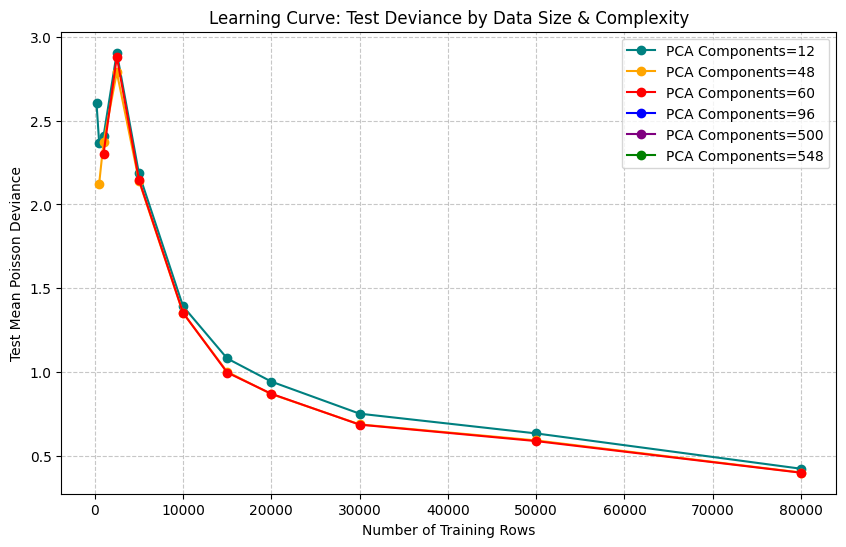

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup & Split
# -------------------------------------------------------
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})

y_train = meta_train['ClaimNb']
offset_train = meta_train['Exposure']

meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

y_test = meta_test['ClaimNb']
offset_test = meta_test['Exposure']


# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Define a comprehensive list of sizes (sorted)
# Includes 200, 1000, and then jumps to 5000, 10000...
train_sizes = [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000]

# Define when each model is allowed to start
start_thresholds = {
    12: 200,
    48: 500,   
    60: 1000,
    96: 1000,
    500: 5000,  # Strictly enforce 500 components starting at 5000 rows
    548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}



# -------------------------------------------------------
# Learning Curve Loop
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data ---
    X_train_sub = X_train.iloc[:size].copy()
    y_train_sub = y_train.iloc[:size]
    off_train_sub = offset_train.iloc[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test)

    del X_train_sub, scaler
    gc.collect()
    
    # --- PCA (Dynamic Fitting) ---
    # We cannot compute 500 components if we only have 200 rows.
    # We fit the maximum possible for this specific iteration.
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state = 42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    del X_train_scaled, X_test_scaled, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        
        # Check 1: User-defined Start Rule (e.g., Don't run 500 if size < 5000)
        if size < start_thresholds[k]:
            results_history[k].append(np.nan)
            continue

        # Check 2: Mathematical Rule (Can't extract 48 components from 12 features)
        if k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice the required components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        # Fit GLM
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            # Score
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

        del X_train_k, X_test_k
        gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # We filter out NaNs so the line connects properly for available data points
    # or keeps gaps where data is missing
    sizes_valid = [s for s, r in zip(train_sizes, results_history[k]) if not np.isnan(r)]
    scores_valid = [r for r in results_history[k] if not np.isnan(r)]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA Components={k}')

plt.title('Learning Curve: Test Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows')
#plt.xscale('log')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
#plt.savefig('lc_comp_pca_fix.png')
plt.show()

## Learning Curves

Size 500: 2.68278
Size 1077: 2.56044
Size 2320: 2.88204
Size 4999: 2.09814
Size 10772: 1.19061
Size 23207: 0.71532
Size 49999: 0.55282
Size 107721: 0.37426
Size 232079: 0.33449
Size 500000: 0.32074


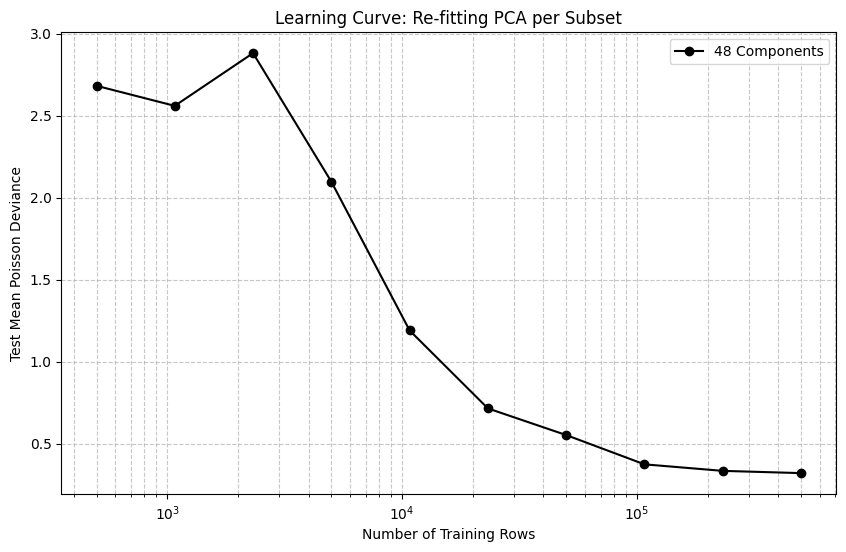

In [10]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import matplotlib.pyplot as plt
# -------------------------------------------------------
# Setup (Using raw X data before PCA)
# -------------------------------------------------------
# Assuming X_train_raw and X_test_raw are your scaled features before PCA
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

y_train = meta_train['ClaimNb']
offset_train = meta_train['Exposure']

y_test = meta_test['ClaimNb']
offset_test = meta_test['Exposure']

# Learning Curve Loop
# -------------------------------------------------------
train_sizesr = np.geomspace(500, 500000, num=10, dtype=int)
deviancesr_2 = []
n_components = 48  # Define your target components here

for size in train_sizesr:
    # Slice the first 'size' rows from RAW data
    X_train_sub_raw = X_train[:size]
    y_train_sub = y_train[:size]
    off_train_sub = offset_train[:size]
    
    # Fit PCA on the current training subset only
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_sub_raw)
    
    # Transform the FIXED Test set using the PCA fitted on the subset
    X_test_pca = pca.transform(X_test)
    
    # Add constants for Statsmodels
    X_train_glm = sm.add_constant(X_train_pca)
    X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
    
    # Fit GLM
    # Note: Use np.log() for the offset in Poisson GLM
    glm = sm.GLM(
        endog=y_train_sub, 
        exog=X_train_glm, 
        offset=np.log(off_train_sub), 
        family=sm.families.Poisson()
    )
    results = glm.fit()
    
    # Predict on transformed Test Set
    preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
    
    # Score
    mpd = mean_poisson_deviance(y_test, preds)
    deviancesr_2.append(mpd)
    print(f"Size {size}: {mpd:.5f}")

# -------------------------------------------------------
# Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(train_sizesr, deviancesr_2, marker='o', color='black', label=f'{n_components} Components')
plt.xscale('log')
plt.title('Learning Curve: Re-fitting PCA per Subset')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()

Textbook beating fine tuned GLM at 48 embeddings, embeddings better at 60 and 96. 48 components does start out much lower than raw data, and appears to be decreasing at a greater rate approaching 40k rows of data (jump of 0.00115 vs 0.00078), so likely has more room for improvement with more data